# Explore hue sensor data: flash_RGY.txt

Loads one session file from `data/hue/raw/`, plots the raw channels, and computes/plots the derived per-stimulus values described in `data/hue/hue.md`.

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.hue.io import load_session
from src.hue.analysis import compute_trial_summary, compute_distance
from src.hue.plotting import plot_raw_channels, plot_trial_summary

## 1. Read the file

In [2]:
data_path = repo_root / "data" / "hue" / "raw" / "data_17JUN26" / "flash_RGY.txt"
df = load_session(data_path)
df.head()

,sample,trCnt,hue_r,hue_g,hue_b,hue_c,hue_colorTemp,hue_lux,currentYellow,currentRed,currentGreen,triggerFlag
0,0,1000,340,452,392,1222,0,4.0,0,0,0,1
1,1,1000,2587,1285,734,4724,5783,316.0,0,0,0,1
2,2,1000,3291,1543,840,5815,2471,651.0,0,0,0,1
3,3,1000,3294,1546,842,5823,2363,752.0,0,0,0,1
4,4,1000,3289,1542,839,5812,2364,754.0,0,0,0,1


## 2. Raw channel plot

Sample number vs `hue_r`, `hue_g`, `hue_b`, all on one figure.

<Axes: xlabel='sample', ylabel='raw ADC count'>

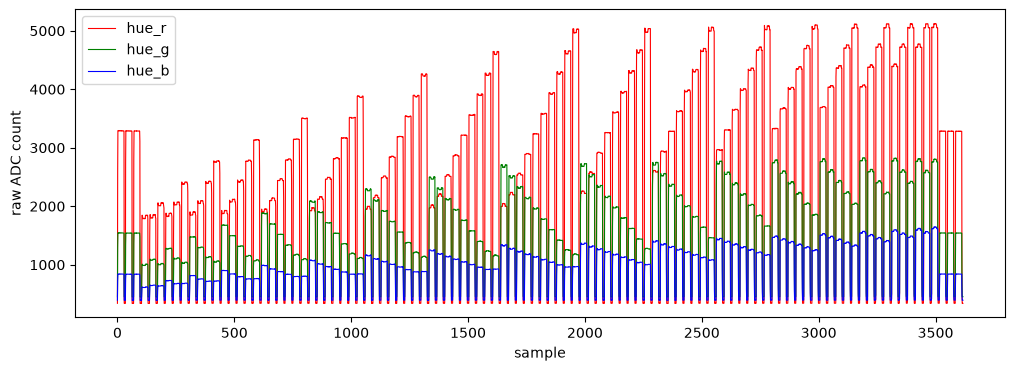

In [3]:
plot_raw_channels(df)

## 3. Derived values per trCnt

Per `hue.md`: for each stimulus trCnt, average the active-stimulus samples (`triggerFlag == 1`), discarding the first 3 samples to let the sensor settle. Baseline is the average of the baseline trials (`trCnt > 999`). Plots mean channel values and baseline-corrected deltas/distance as a function of trCnt.

In [4]:
summary = compute_trial_summary(df)
summary.head()

,trCnt,meanHueR,meanHueG,meanHueB,deltaR,deltaG,deltaB,distance
0,1,1815.916667,997.416667,614.875000,1469.121944,544.474722,224.669444,1582.797640
1,2,1830.400000,1086.080000,648.120000,1454.638611,455.811389,191.424444,1536.353094
2,3,2035.360000,1011.080000,639.360000,1249.678611,530.811389,200.184444,1372.418002
3,4,1855.041667,1275.083333,728.416667,1429.996944,266.808056,111.127778,1458.913014
4,5,2045.791667,1107.416667,676.708333,1239.246944,434.474722,162.836111,1323.259941


array([<Axes: ylabel='mean raw count'>,
       <Axes: xlabel='trCnt', ylabel='baseline-corrected'>], dtype=object)

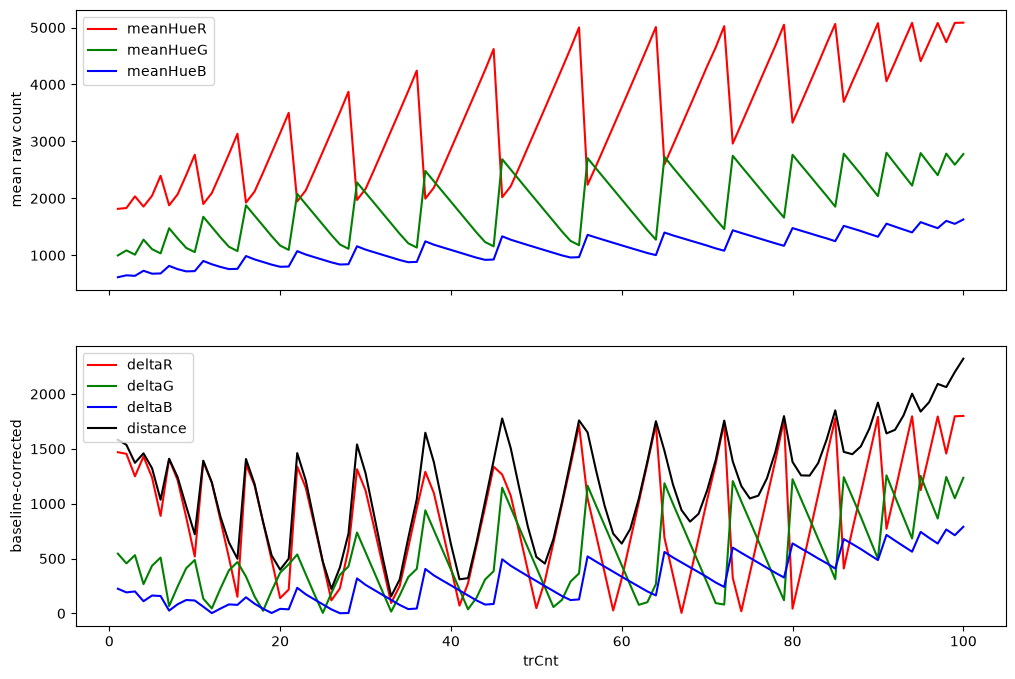

In [5]:
plot_trial_summary(summary)

## 4. Distance for a chosen channel combination

`compute_distance(summary, channels=...)` lets you restrict the distance metric to any subset of R/G/B (e.g. just RG, or a single channel) without recomputing the per-trial means.

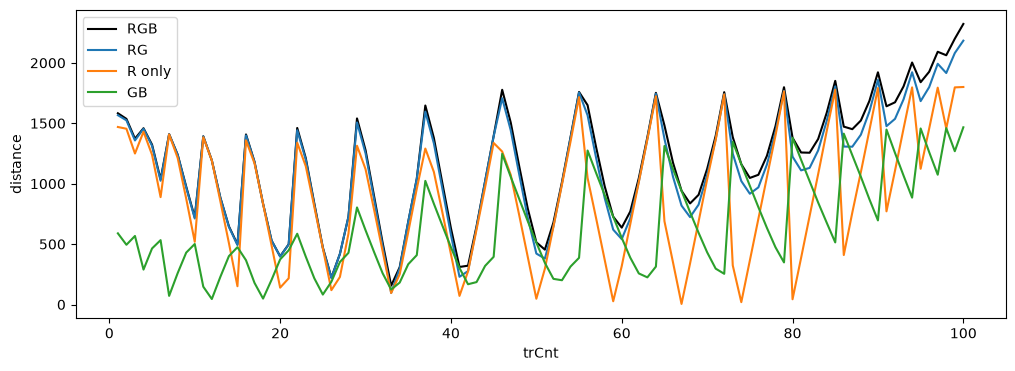

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(summary["trCnt"], summary["distance"], label="RGB", color="black")
ax.plot(summary["trCnt"], compute_distance(summary, channels=("R", "G")), label="RG")
ax.plot(summary["trCnt"], compute_distance(summary, channels=("R",)), label="R only")
ax.plot(summary["trCnt"], compute_distance(summary, channels=("G", "B")), label="GB")
ax.set_xlabel("trCnt")
ax.set_ylabel("distance")
ax.legend()